In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
columns = [
    'id', 'diagnosis',

    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',

    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',

    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df = pd.read_csv('/content/wdbc.data', header=None, names=columns)

In [42]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [43]:
df.shape

(569, 32)

In [44]:
df.to_csv('cancer_data.csv', index=False)

from google.colab import files
files.download('cancer_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [47]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


/tmp/ipykernel_1966/4217252138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


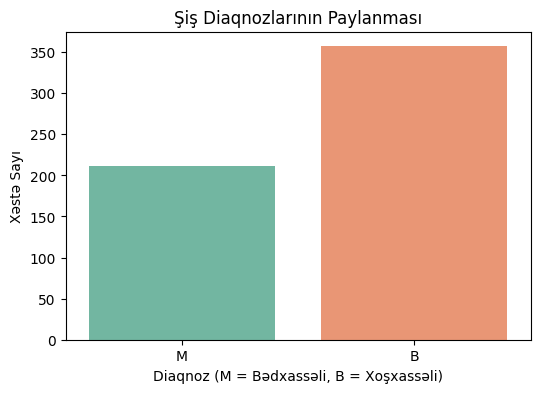

In [48]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Şiş Diaqnozlarının Paylanması')
plt.xlabel('Diaqnoz (M = Bədxassəli, B = Xoşxassəli)')
plt.ylabel('Xəstə Sayı')

plt.show()

In [49]:
df.isnull().sum().sum()

np.int64(0)

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.drop(columns=['id'], inplace=True)

In [52]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
le = LabelEncoder()

In [55]:
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [56]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


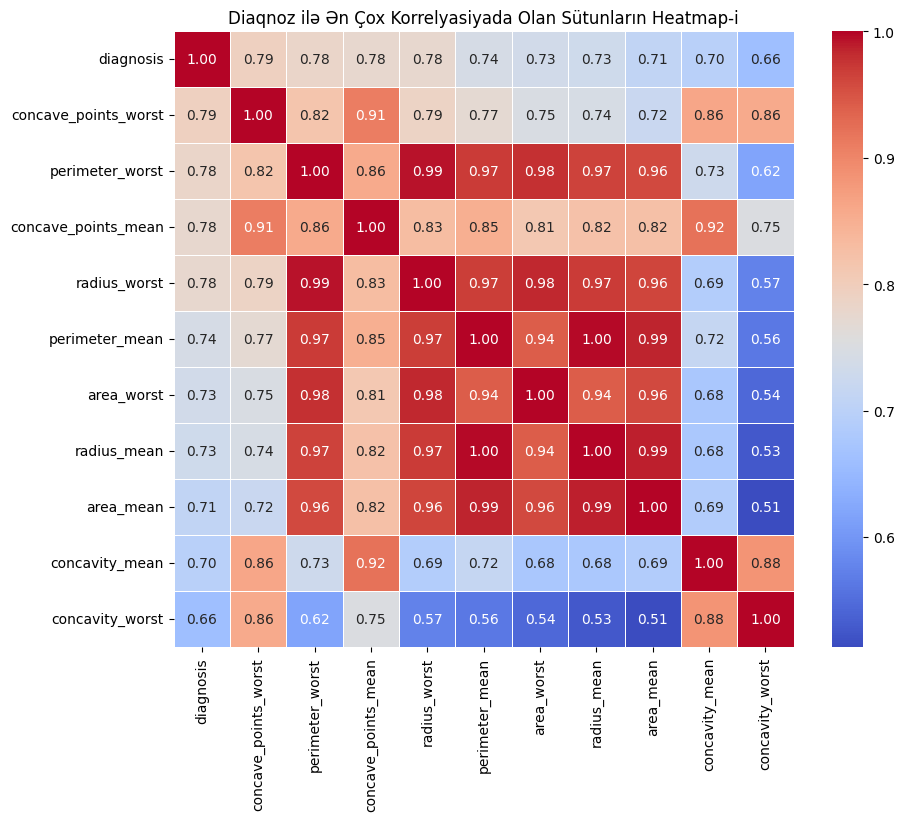

In [57]:
top_corr_features = df.corr()['diagnosis'].sort_values(ascending=False).index[:11]

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Diaqnoz ilə Ən Çox Korrelyasiyada Olan Sütunların Heatmap-i')
plt.show()

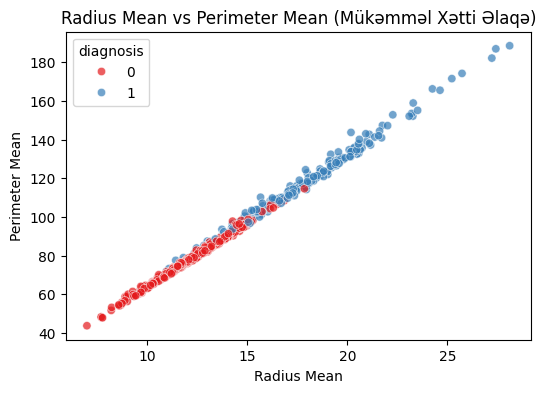

In [58]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='radius_mean', y='perimeter_mean', hue='diagnosis', data=df, palette='Set1', alpha=0.7)
plt.title('Radius Mean vs Perimeter Mean (Mükəmməl Xətti Əlaqə)')
plt.xlabel('Radius Mean')
plt.ylabel('Perimeter Mean')
plt.show()

/tmp/ipykernel_1966/2437221721.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette='pastel')
/tmp/ipykernel_1966/2437221721.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette='pastel')
/tmp/ipykernel_1966/2437221721.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=df, palette='pastel')
/tmp/ipykernel_1966/2437221721.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign th

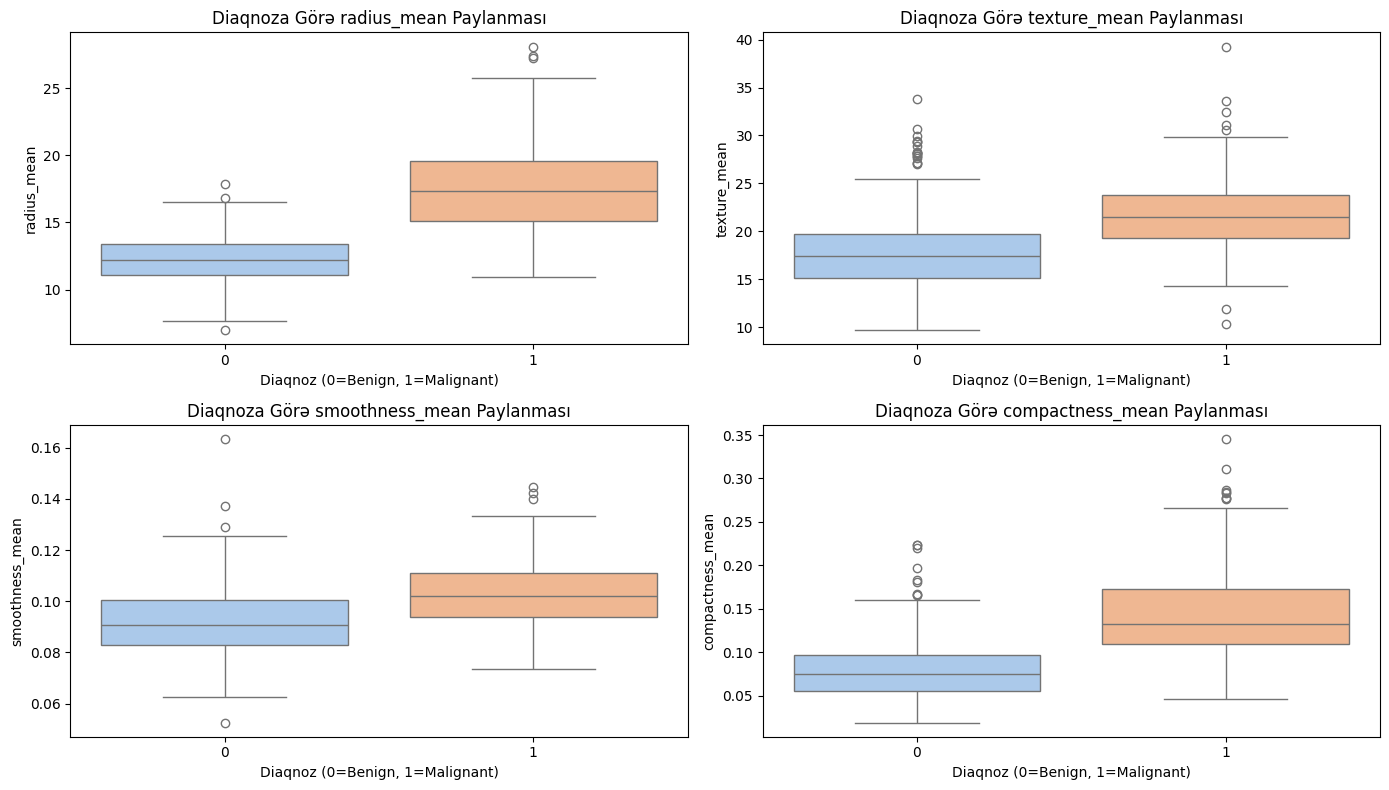

In [59]:
features_to_plot = ['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean']

plt.figure(figsize=(14, 8))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='diagnosis', y=col, data=df, palette='pastel')
    plt.title(f'Diaqnoza Görə {col} Paylanması')
    plt.xlabel('Diaqnoz (0=Benign, 1=Malignant)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [61]:
X = df.drop(columns=['diagnosis'])

In [62]:
y = df['diagnosis']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
X_train.shape

(455, 30)

In [65]:
X_test.shape

(114, 30)

In [66]:
scaler = StandardScaler()

In [67]:
X_train_scaled = scaler.fit_transform(X_train)

In [68]:
X_test_scaled = scaler.transform(X_test)

In [69]:
X_train_scaled[0][:5]

array([ 0.51855873,  0.89182579,  0.4246317 ,  0.38392544, -0.97474371])

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [71]:
log_reg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', random_state=42)

log_reg.fit(X_train_scaled, y_train)

knn.fit(X_train_scaled, y_train)

svm.fit(X_train_scaled, y_train)

print(f"Logistic Regression Accuracy: {log_reg.score(X_test_scaled, y_test)}")
print(f"KNN Accuracy: {knn.score(X_test_scaled, y_test)}")
print(f"SVM Accuracy: {svm.score(X_test_scaled, y_test)}")

Logistic Regression Accuracy: 0.9649122807017544
KNN Accuracy: 0.956140350877193
SVM Accuracy: 0.9736842105263158


In [72]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

Model: Logistic Regression
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



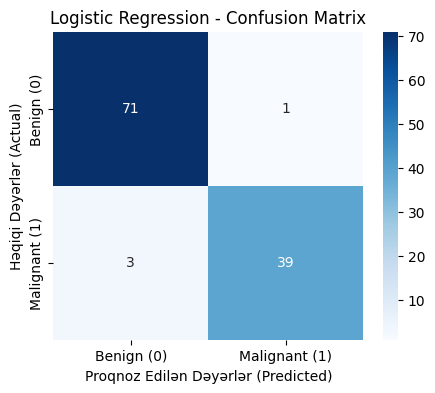

Model: K-Nearest Neighbors (KNN)
               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97        72
Malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



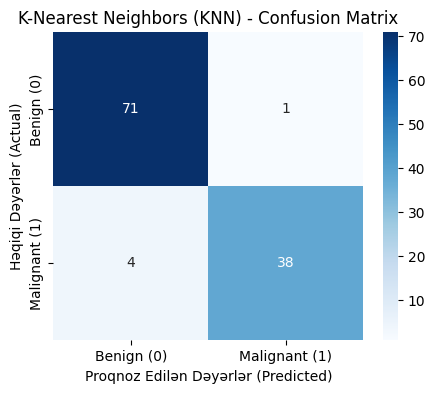

Model: Support Vector Machines (SVM)
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



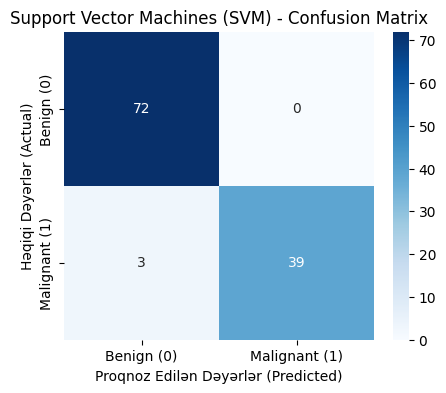

In [75]:
models = {
    "Logistic Regression": log_reg,
    "K-Nearest Neighbors (KNN)": knn,
    "Support Vector Machines (SVM)": svm
}

for name, model in models.items():
  y_pred = model.predict(X_test_scaled)

  print(f"Model: {name}")

  print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(5, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign (0)', 'Malignant (1)'],
                yticklabels=['Benign (0)', 'Malignant (1)'])
  plt.title(f'{name} - Confusion Matrix')
  plt.ylabel('Həqiqi Dəyərlər (Actual)')
  plt.xlabel('Proqnoz Edilən Dəyərlər (Predicted)')
  plt.show()